## 4. Isolation Forest (iForest)

In [2]:
#!pip install pyod
#!pip install combo

In [4]:
######################
# Helper functions
######################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data

def DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
):
    """
    Data Generating Process (DGP) for anomaly detection examples.

    Parameters
    ----------
    contamination : float
        Percentage of outliers
    n_train : int
        Number of training samples
    n_test : int
        Number of test samples
    n_features : int
        Number of features
    random_state : int
        Seed for reproducibility
    shift : bool
        Apply transformation (e.g., 5 - X)
    return_df : bool
        Return pandas DataFrame if True

    Returns
    -------
    X_train, X_test, y_train, y_test
    """

    X_train, X_test, y_train, y_test = generate_data(
        n_train=n_train,
        n_test=n_test,
        n_features=n_features,
        contamination=contamination,
        random_state=random_state
    )

    X_train = 5 - X_train
    X_test = 5 - X_test

    if return_df:
        X_train = pd.DataFrame(X_train)
        X_test = pd.DataFrame(X_test)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)

def plot_generated_data(x1,x2,y_train):
    # Plot
    plt.scatter(x1, x2, c=y_train, alpha=0.8)
    plt.title('Scatter plot')
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.show()

def evaluate_model(model, X_train, X_test):
    """
    Generate scores, predictions, and threshold for train and test data.

    Parameters
    ----------
    model : trained model
    X_train : array-like
    X_test : array-like

    Returns
    -------
    results : dict
        Contains scores, 
        predictions, and 
        threshold
    """

    results = {
        "train_scores": model.decision_function(X_train),
        "train_pred": model.predict(X_train),
        "test_scores": model.decision_function(X_test),
        "test_pred": model.predict(X_test),
        "threshold": getattr(model, "threshold_", None)
    }

    return results

def count_stat(vector):
    # Because it is '0' and '1', we can run a count statistic.
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

def plot_hist(scores, title="Outlier Score"):
    """
    Plot histogram of outlier scores.

    Parameters
    ----------
    scores : array-like
        Outlier scores
    title : str
        Title of the plot
    """

    plt.hist(scores, bins='auto')
    plt.title(title)
    plt.show()

def descriptive_stat_threshold(X, scores, threshold, feature_names=None):
    """
    Generate descriptive statistics for normal and outlier groups.

    Parameters
    ----------
    X : array-like
        Input data
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers
    feature_names : list, optional
        Feature names for labeling columns

    Returns
    -------
    summary : DataFrame
        Count, percentage, and mean statistics by group
    """

    df = pd.DataFrame(X)

    # Assign feature names if provided
    if feature_names:
        df.columns = feature_names

    # Add score and group label
    df["Anomaly_Score"] = scores
    df["Group"] = np.where(df["Anomaly_Score"] < threshold, "Normal", "Outlier")

    # Count and percentage
    count = (
        df.groupby("Group")["Anomaly_Score"]
        .count()
        .reset_index()
        .rename(columns={"Anomaly_Score": "Count"})
    )
    count["Count %"] = count["Count"] / count["Count"].sum() * 100

    # Mean statistics
    stats = (
        df.groupby("Group")
        .mean(numeric_only=True)
        .round(2)
        .reset_index()
    )

    # Merge results
    summary = count.merge(stats, on="Group")

    return summary

def confusion_matrix(actual, scores, threshold):
    """
    Create a confusion matrix using actual labels and outlier scores.

    Parameters
    ----------
    actual : array-like
        True labels (0 = normal, 1 = outlier)
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers

    Returns
    -------
    cm : DataFrame
        Confusion matrix
    """

    df = pd.DataFrame({
        "Actual": actual,
        "Score": scores
    })

    # Convert scores to predicted labels
    df["Pred"] = np.where(df["Score"] <= threshold, 0, 1)

    # Generate confusion matrix
    cm = pd.crosstab(df["Actual"], df["Pred"])

    return cm

In [5]:
X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)

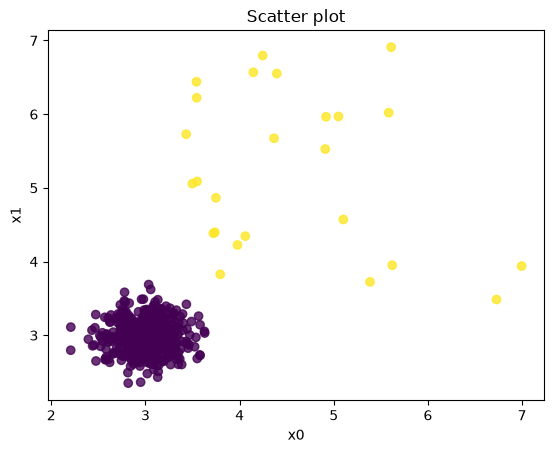

In [6]:
plot_generated_data(X_train[0],X_train[1],y_train)

### Step 1: Build the model

In [7]:
from pyod.models.iforest import IForest
isft = IForest(contamination=0.05, max_samples=40, behaviour='new')
isft.fit(X_train)

,max_samples,40
,contamination,0.05
,behaviour,'new'
,n_estimators,100
,max_features,1.0
,bootstrap,False
,n_jobs,1
,random_state,None
,verbose,0
Name,Type,Value
decision_scores_,"ndarray[float64](500,)","[-0.11,-0.09,-0.1 ,..., 0.17, 0.18, 0.24]"


In [8]:
isft.get_params()

{'behaviour': 'new',
 'bootstrap': False,
 'contamination': 0.05,
 'max_features': 1.0,
 'max_samples': 40,
 'n_estimators': 100,
 'n_jobs': 1,
 'random_state': None,
 'verbose': 0}

In [9]:
isft_vi = isft.feature_importances_
isft_vi

array([0.18857917, 0.15821872, 0.19360438, 0.16807186, 0.14713556,
       0.14439031])

<Axes: >

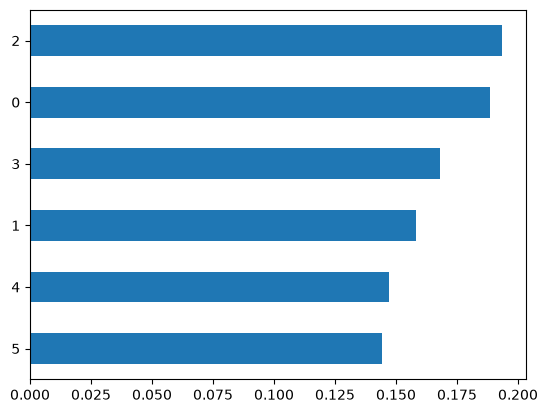

In [11]:
from matplotlib import pyplot as plt
for_plot = pd.DataFrame({'x_axis':X_train.columns, 'y_axis':isft_vi}).sort_values(by='y_axis',ascending=True)
for_plot['y_axis'].plot.barh()

In [12]:
results = evaluate_model(isft, X_train, X_test)

y_train_scores = results["train_scores"]
y_train_pred = results["train_pred"]

y_test_scores = results["test_scores"]
y_test_pred = results["test_pred"]

threshold = results["threshold"]

### Step 2: Determine the threshold

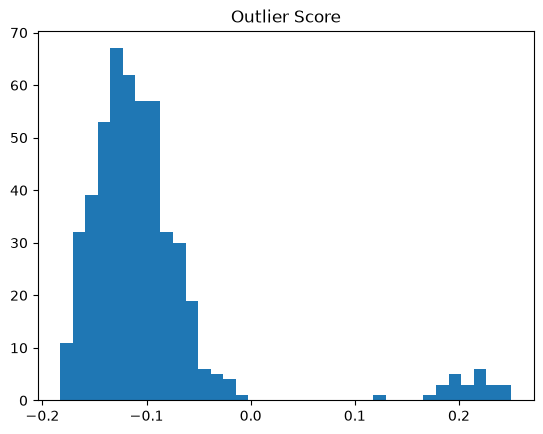

In [13]:
plot_hist(y_train_scores)

### Step 3: Descriptive statistics

In [14]:
feature_list = ['F1','F2','F3','F4','F5','F6']
descriptive_stat_threshold(X_train,y_train_scores, threshold)

,Group,Count,Count %,0,1,2,3,4,5,Anomaly_Score
0,Normal,475,95.0,3.00,2.99,2.99,3.01,2.99,3.02,-0.11
1,Outlier,25,5.0,4.55,5.21,5.47,5.23,5.03,5.06,0.21


In [15]:
descriptive_stat_threshold(X_test,y_test_scores, threshold)

,Group,Count,Count %,0,1,2,3,4,5,Anomaly_Score
0,Normal,475,95.0,2.98,2.99,2.99,3.01,2.99,3.00,-0.11
1,Outlier,25,5.0,5.00,5.54,5.23,5.05,5.06,4.88,0.21


### Step 4: Averages

In [17]:
from pyod.models.combination import aom, moa, average, maximization
from pyod.utils.utility import standardizer
from pyod.models.iforest import IForest

# Standardize data
X_train_norm, X_test_norm = standardizer(X_train, X_test)

# Test a range of maximum samples
k_list = [20, 30, 40, 50, 60]
k_list = [100, 200, 300, 400, 500]
n_clf = len(k_list)
# Just prepare data frames so we can store the model results
train_scores = np.zeros([X_train.shape[0], n_clf])
test_scores = np.zeros([X_test.shape[0], n_clf])

# Modeling
for i in range(n_clf):
    k = k_list[i]
    #isft = IForest(contamination=0.05, max_samples=k)
    isft = IForest(contamination=0.05, n_estimators=k)
    isft.fit(X_train_norm)

    # Store the results in each column:
    train_scores[:, i] = isft.decision_function(X_train_norm)
    test_scores[:, i] = isft.decision_function(X_test_norm)
# Decision scores have to be normalized before combination
train_scores_norm, test_scores_norm = standardizer(train_scores,test_scores)

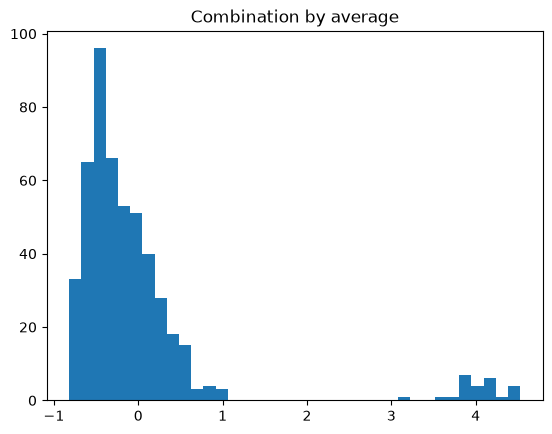

In [19]:
# Combination by average
# The test_scores_norm is 500 x 10. The "average" function will take the average of the 10 columns. The result "y_by_average" is a single column:
y_train_by_average = average(train_scores_norm)
y_test_by_average = average(test_scores_norm)
import matplotlib.pyplot as plt
plt.hist(y_train_by_average, bins='auto') # arguments are passed to np.histogram
plt.title("Combination by average")
plt.show()

In [20]:
descriptive_stat_threshold(X_train,y_train_by_average, 1.5)

,Group,Count,Count %,0,1,2,3,4,5,Anomaly_Score
0,Normal,475,95.0,3.00,2.99,2.99,3.01,2.99,3.02,-0.21
1,Outlier,25,5.0,4.55,5.21,5.47,5.23,5.03,5.06,4.05


In [21]:
descriptive_stat_threshold(X_test,y_test_by_average, 1.5)

,Group,Count,Count %,0,1,2,3,4,5,Anomaly_Score
0,Normal,475,95.0,2.98,2.99,2.99,3.01,2.99,3.00,-0.19
1,Outlier,25,5.0,5.00,5.54,5.23,5.05,5.06,4.88,4.12
